In [1]:
from urllib.request import urlretrieve
import pyopenms as oms

gh = "https://raw.githubusercontent.com/OpenMS/pyopenms-docs/master"
urlretrieve(
    gh + "/src/data/YIC(Carbamidomethyl)DNQDTISSK.mzML", "observed.mzML"
)

exp = oms.MSExperiment()
# Load mzML file and obtain spectrum for peptide YIC(Carbamidomethyl)DNQDTISSK
oms.MzMLFile().load("observed.mzML", exp)

# Get first spectrum
spectra = exp.getSpectra()
observed_spectrum = spectra[0]

In [2]:
tsg = oms.TheoreticalSpectrumGenerator()
theo_spectrum = oms.MSSpectrum()
p = tsg.getParameters()
p.setValue("add_y_ions", "true")
p.setValue("add_b_ions", "true")
p.setValue("add_metainfo", "true")
tsg.setParameters(p)
peptide = oms.AASequence.fromString("YIC(Carbamidomethyl)DNQDTISSK")
tsg.getSpectrum(theo_spectrum, peptide, 1, 2)

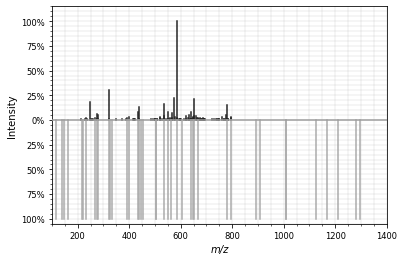

In [3]:
import matplotlib.pyplot as plt
from pyopenms.plotting import mirror_plot_spectrum
import matplotlib.pyplot as plt

mirror_plot_spectrum(
    observed_spectrum,
    theo_spectrum,
    spectrum_bottom_kws={"annotate_ions": False},
)
plt.show()